# Pràctica 2: Aprenentatge no supervisat

**Universitat Rovira i Virgili (URV)** | Departament d'Enginyeria Informàtica i Matemàtiques  
**Assignatura:** Aprenentatge Automàtic i Mineria de Dades (AAMD) - GEI + GEMF (2025-26)
### **Autors:**
* #### Hugo Miranda Serrano
* #### Marcel Díaz Serra
### **Grup:** W
---
**Abstract**: This *notebook* documents the process of applying, evaluating and algorithmically comparing six unsupervised learning techniques (*Principal Component Analysis*, *t-SNE*, *K-Means*, *Agglomerative Hierarchical Clustering*, *Autoencoders* and *Self-Organizing Maps*). The analysis is carried out on two vector spaces of different natures (a synthetic and a real one) with the aim of uncovering their underlying topological structure and evaluating the strengths and limitations of each model.

---

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import os
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("notebook", font_scale=1.1)

plt.rcParams.update({'figure.dpi': 120, 'font.family': 'sans-serif'})
sns.set_theme(style="whitegrid")

# 1. Ingesta y Pre-procesamiento de Datos

El éxito depende de la calidad de la representación vectorial de entrada. En esta fase, abordamos dos desafíos:

1. **Parsing Dinámico:** Dado que los conjuntos de datos `A2-synthetic.txt` y `A2-real.txt` poseen estructuras de delimitación distintas (comas y puntos y coma respectivamente), se implementó una lógica de carga robusta para garantizar la integridad de las matrices de características ($X$).
2. **Estandarización (Z-score Scaling):** Algunos algoritmos (PCA, K-Means, AHC) se basan en la maximización de la varianza o en el cálculo de distancias Euclidianas. Si las variables poseen escalas diferentes, aquellas con magnitudes numéricas mayores dominarán artificialmente el modelo. Se aplica la transformación:
$$z = \frac{x - \mu}{\sigma}$$

        Asegurando que cada característica contribuya equitativamente al aprendizaje, con media 0 y varianza 1.

### Análisis de Datos

* **Dataset Sintético:** 360 patrones con 4 variables continuas. Se aisló la clase para evaluación posterior.
* **Dataset Real:** 333 patrones con 5 variables físicas. Se extrajeron etiquetas de clase y localización para validación extrínseca.

In [2]:
def load_and_preprocess_data(filepath: str, is_real_dataset: bool = False) -> tuple:
    """
    Parses the dataset using the empirically observed delimiters, isolates
    feature matrices from meta-labels, and applies Z-score standardization.
    """
    # Dynamic delimiter assignment based on file
    delimiter = ';' if is_real_dataset else ','

    df = pd.read_csv(filepath, sep=delimiter)

    if is_real_dataset:
        # A2-real: 5 features, 1 location, 1 class
        feature_cols = df.columns[:-2]
        X_raw = df[feature_cols].values
        metadata = {
            'labels': df.iloc[:, -1].values,
            'locations': df.iloc[:, -2].values
        }
    else:
        # A2-synthetic: 4 features, 1 class
        feature_cols = df.columns[:-1]
        X_raw = df[feature_cols].values
        metadata = {'labels': df.iloc[:, -1].values}

    # apply Z-score standardization: (x - mu) / sigma
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_raw)

    return X_scaled, metadata, feature_cols

# init tensor variables
X_syn, meta_syn, cols_syn = load_and_preprocess_data('A2-synthetic.txt', is_real_dataset=False)
X_real, meta_real, cols_real = load_and_preprocess_data('A2-real.txt', is_real_dataset=True)

print(f"Synthetic tensor -> X shape: {X_syn.shape} (Expected: 360, 4)")
print(f"Real tensor      -> X shape: {X_real.shape} (Expected: 333, 5)")

Synthetic tensor -> X shape: (360, 4) (Expected: 360, 4)
Real tensor      -> X shape: (333, 5) (Expected: 333, 5)


---

# 2. Principal Component Analysis (PCA)

### Fundamento

PCA es una técnica de reducción de dimensionalidad lineal que busca proyectar los datos en un nuevo subespacio ortogonal. El objetivo es maximizar la varianza retenida de los datos.
Partiendo de la matriz estandarizada *$X$*, se resuelve la descomposición de autovalores de la matriz de covarianza $\Sigma = \frac{1}{n-1} X^T X$:

$$\Sigma v_i = \lambda_i v_i$$

Donde los **autovectores** ($v_i$) definen las direcciones de los componentes principales de máxima varianza y los **autovalores** ($\lambda_i$) cuantifican la varianza explicada por cada componente. El rátio de varianza explicado para el componente $k$-ésimo se define como $\frac{\lambda_k}{\sum \lambda_j}$.

### Justificación de la Trayectoria

Se seleccionaron **2 componentes principales** para cumplir con el requisito de visualización en el plano $X-Y$. Además, se generó un **Scree Plot** para diagnosticar la compresibilidad de los datos.

--- PCA Analysis: Synthetic Dataset ---


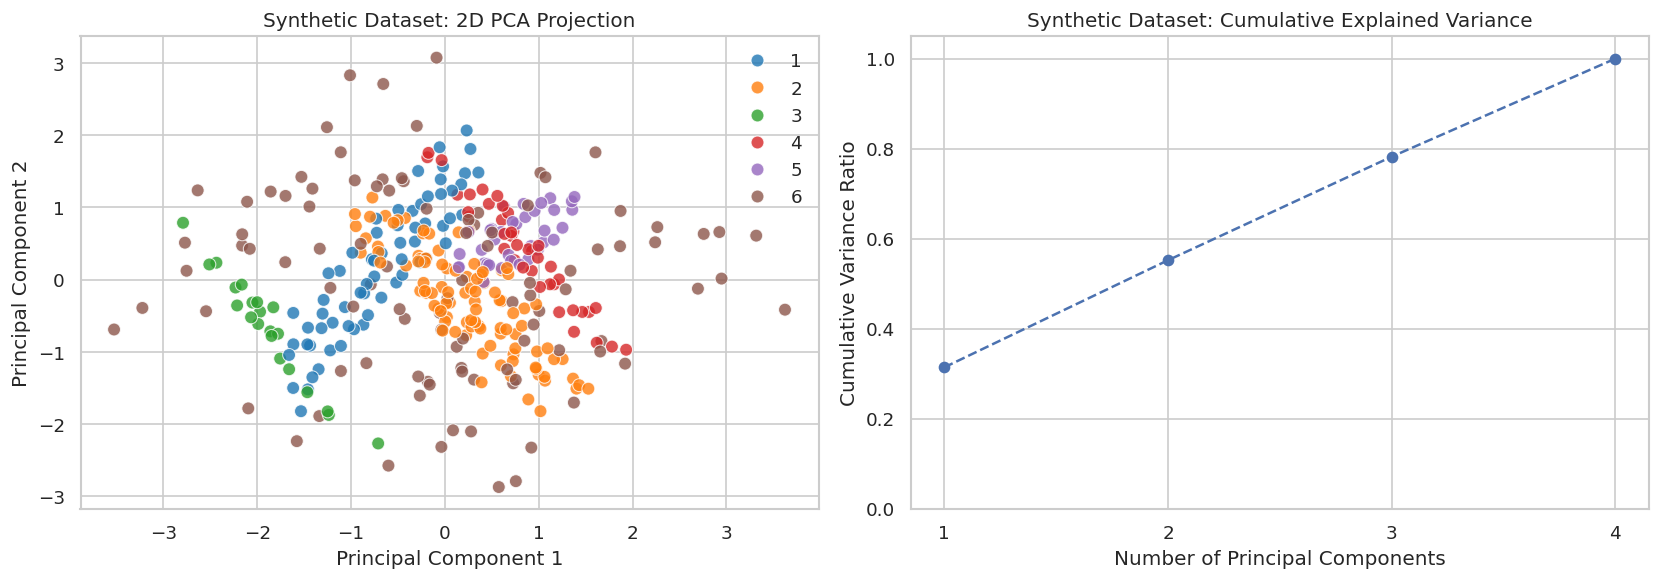


--- PCA Analysis: Real Dataset ---


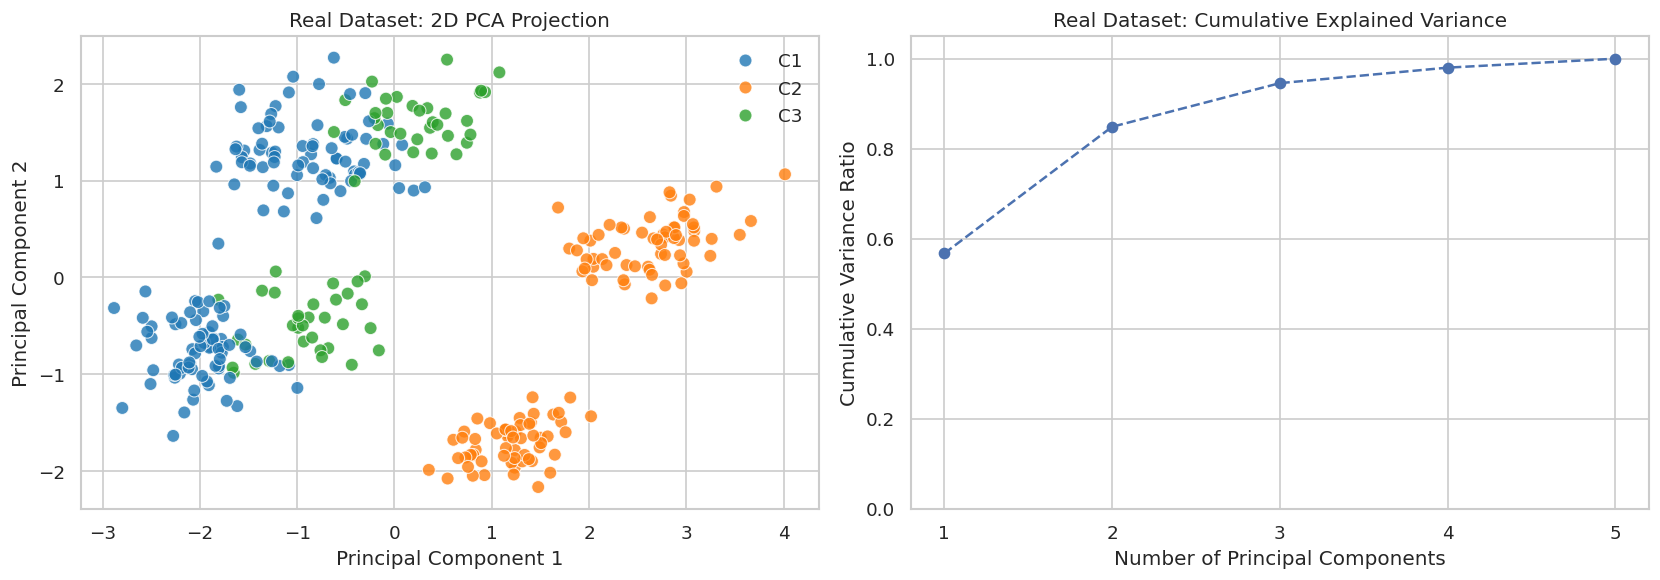

In [3]:
#PCA
from sklearn.decomposition import PCA

def execute_pca_pipeline(X: np.ndarray, labels: np.ndarray, dataset_name: str) -> np.ndarray:
    """
    Computes PCA transformation, plots the 2D projection colored by class,
    and generates the cumulative variance scree plot.
    """
    # instantiate PCA keeping all components to calculate full variance spectrum
    pca = PCA()
    X_pca_full = pca.fit_transform(X)

    # 2D projection requirement
    X_pca_2d = X_pca_full[:, :2]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Plot 1: 2D Latent Space Projection
    sns.scatterplot(
        x=X_pca_2d[:, 0],
        y=X_pca_2d[:, 1],
        hue=labels,
        palette='tab10',
        ax=axes[0],
        s=60,
        alpha=0.8,
        legend='full'
    )
    axes[0].set_title(f'{dataset_name}: 2D PCA Projection')
    axes[0].set_xlabel('Principal Component 1')
    axes[0].set_ylabel('Principal Component 2')

    # Plot 2: Scree Plot (Cumulative Variance)
    cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
    axes[1].plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='--')
    axes[1].set_title(f'{dataset_name}: Cumulative Explained Variance')
    axes[1].set_xlabel('Number of Principal Components')
    axes[1].set_ylabel('Cumulative Variance Ratio')
    axes[1].set_ylim(0, 1.05)
    axes[1].set_xticks(range(1, len(cumulative_variance) + 1))

    plt.tight_layout()
    plt.show()

    return X_pca_2d

print("--- PCA Analysis: Synthetic Dataset ---")
X_syn_pca = execute_pca_pipeline(X_syn, meta_syn['labels'], "Synthetic Dataset")

print("\n--- PCA Analysis: Real Dataset ---")
X_real_pca = execute_pca_pipeline(X_real, meta_real['labels'], "Real Dataset")

### Análisis Resultados (PCA)

La observación paralela del espacio latente (*Scatter Plot*) y la capacidad de retención de información (*Scree Plot*) nos permite extraer información cada *dataset*:

* **Synthetic Dataset (No linealidad subyacente):**
    * La varianza acumulada sufre una degradación drástica, logrando retener apenas un **~55%** de la información en el plano 2D. Se perdie casi la mitad de la expresividad del sistema al colapsar de 4D a 2D.
    * Visualmente, se manifiesta como un colapso topológico (un *blob* solapado): las seis clases aparecen superpuestas y visualmente inseparables.
    * Esto no implica que los datos sintéticos carezcan de estructura. Indica que el *dataset* posee **topologías no lineales complejas** (ej. curvas cerradas, anillos). PCA, al ser una proyección basada estrictamente en hiperplanos, es matemáticamente incapaz de "desenrollar" estas estructuras.
* **Real Dataset (Alta linealidad):**
    * El análisis del espectro revela que solo 2 componentes principales son suficientes para retener aproximadamente el **85% de la varianza total** del hiperespacio original de 5 dimensiones.
    * Gracias a esta alta capacidad de explicación lineal, la proyección 2D muestra clústeres densos y altamente separables. La topología original se preserva de buena forma en un plano rígido.
---

## 3. t-Distributed Stochastic Neighbor Embedding (t-SNE)

### Fundamento
A diferencia de PCA, t-SNE es una técnica de reducción de dimensionalidad **no lineal** y estocástica. Su objetivo principal es modelar y conservar la **topología local** (las vecindades) de los datos de alta dimensionalidad en un espacio bidimensional o tridimensional.

El algoritmo opera transformando las distancias Euclidianas entre puntos en probabilidades condicionales que representan similitudes:
1.  **En el hiperespacio original:** Modela las afinidades utilizando una distribución Gaussiana.
2.  **En el espacio latente (2D):** Emplea una distribución t de Student (con un grado de libertad). Las colas pesadas de esta distribución benefician al problema de aglomeración (*crowding problem*), permitiendo que puntos moderadamente distantes se separen adecuadamente en el plano.

El modelo se entrena minimizando la **Divergencia de Kullback-Leibler (KL)** entre ambas distribuciones probabilísticas mediante descenso de gradiente.

### Justificación del Perplexity
El comportamiento de t-SNE está fuertemente marcado por el hiperparámetro *perplexity*. Este valor puede interpretarse como una medida continua del número efectivo de vecinos locales que el algoritmo debe considerar.
Para diagnosticar la estructura geométrica de nuestros datos, no basta con una única ejecución. Se diseña una **grid search** evaluando un espectro amplio de perplexities: `[5, 10, 20, 30, 50, 100, 300]`. Esto permite observar la transición desde un enfoque extremadamente local (bajo prioriza captura micro-estructuras) hasta un enfoque global (alto prioriza captura geometría global del manifold).

--- t-SNE Optimization: Synthetic Dataset ---


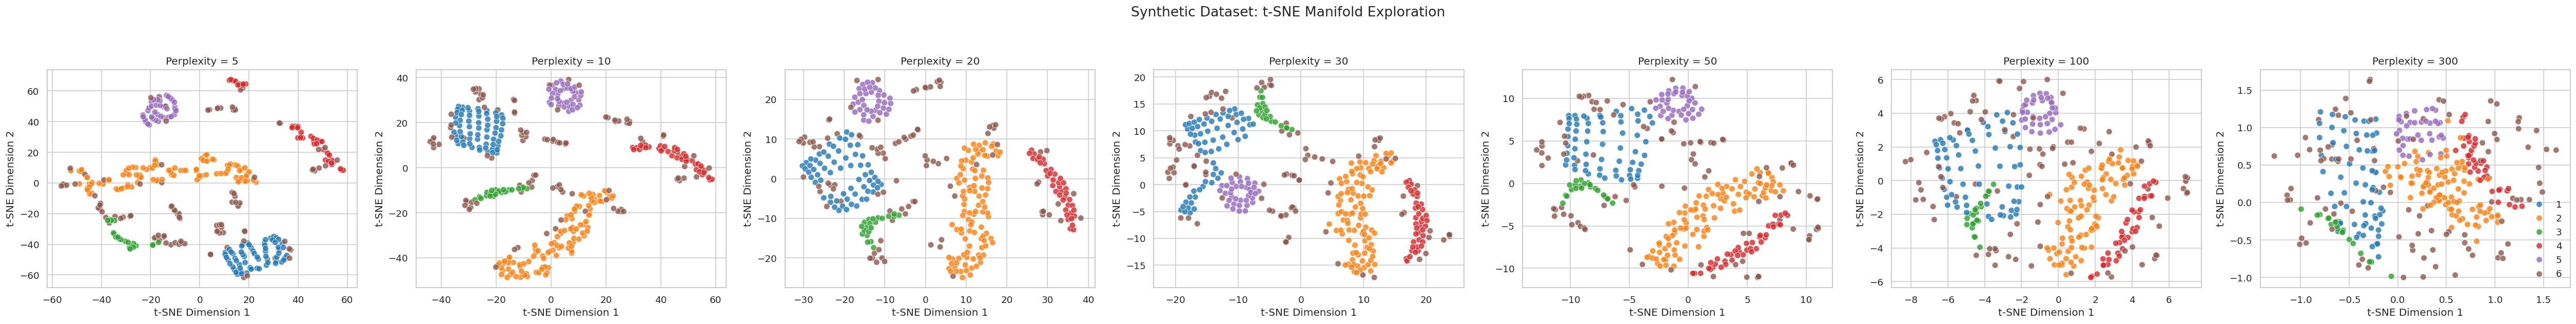


--- t-SNE Optimization: Real Dataset ---


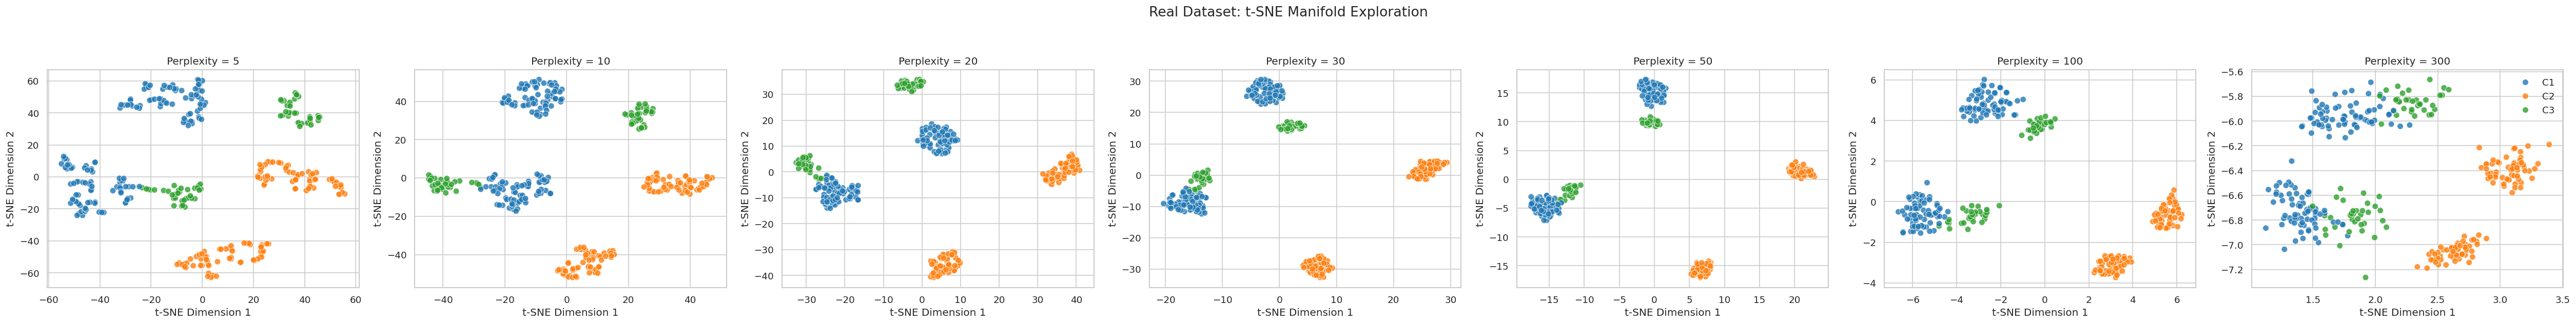

In [4]:
#t-SNE
from sklearn.manifold import TSNE

def evaluate_tsne_perplexities(X: np.ndarray, labels: np.ndarray, dataset_name: str, perplexities: list, save_dir: str = './plots'):
    """
    Computes and plots t-SNE 2D projections for a given list of perplexity values.
    Demonstrates the impact of the effective neighborhood size on local topology.
    """
    n_plots = len(perplexities)
    # Define a 1xN grid for the subplots based on the number of perplexities
    fig, axes = plt.subplots(1, n_plots, figsize=(6 * n_plots, 5))

    if n_plots == 1:
        axes = [axes] # ensure iterable if only one perplexity is passed

    for i, perplexity in enumerate(perplexities):
        tsne = TSNE(
            n_components=2,
            perplexity=perplexity,
            random_state=42,
            init='pca',
            learning_rate='auto'
        )

        # fit and transform the standardized feature matrix
        X_tsne = tsne.fit_transform(X)

        # plot the 2D latent space
        sns.scatterplot(
            x=X_tsne[:, 0],
            y=X_tsne[:, 1],
            hue=labels,
            palette='tab10',
            ax=axes[i],
            s=50,
            alpha=0.8,
            legend='full' if i == n_plots - 1 else False
        )

        axes[i].set_title(f'Perplexity = {perplexity}')
        axes[i].set_xlabel('t-SNE Dimension 1')
        axes[i].set_ylabel('t-SNE Dimension 2')

    fig.suptitle(f'{dataset_name}: t-SNE Manifold Exploration', fontsize=16, y=1.05)
    plt.tight_layout()

    filename = f"{dataset_name.replace(' ', '_').lower()}_tsne_grid.png"
    filepath = os.path.join(save_dir, filename)
    fig.savefig(filepath, dpi=300, bbox_inches='tight')

    plt.show()

# define hyperparameter grid: extremely local, standard, and global limits
perplexity_grid = [5, 10, 20, 30, 50, 100, 300]

print("--- t-SNE Optimization: Synthetic Dataset ---")
evaluate_tsne_perplexities(X_syn, meta_syn['labels'], "Synthetic Dataset", perplexity_grid)

print("\n--- t-SNE Optimization: Real Dataset ---")
evaluate_tsne_perplexities(X_real, meta_real['labels'], "Real Dataset", perplexity_grid)

### Análisis Resultados (t-SNE)

La iteración paramétrica sobre el valor de *perplexity* nos proporciona una radiografía topológica de ambos espacios vectoriales, confirmando:

* **Synthetic Dataset (descubrimiento del *manifold*):**
    * **Rango de alta resolución ($P \in [5, 50]$):** El algoritmo revela estructuras subyacentes altamente complejas. Se observa cómo las clases conforman geometrías no lineales: anillos toroidales, distribuciones espaciales en cuadrícula y trayectorias sinusoidales. t-SNE logra desenrollar en parte el *manifold* que PCA había colapsado, demostrando que la separabilidad de estas clases reside en sus relaciones de vecindad locales.
    * **Colapso global ($P \ge 100$):** Dado que el dataset consta de 360 patrones, forzar un perplexity de 100 o 300 obliga a considerar a casi todos los puntos como vecinos locales. Al intentar preservar distancias globales, la optimización KL colapsa la estructura fina y devuelve un amasijo denso de puntos.
* **Real Dataset (robustez estructural):**
    * La proyección de este conjunto de datos demuestra no mucha variabilidad entre los diferentes *perplexities* centrales. Los tres clústeres originados en el espacio 5D se mantienen rígidamente separados y cohesionados en gran parte del espectro evaluado.
    * Esto puede suponer que las tres clases reales no solo poseen una varianza explicable linealmente (como se vio en PCA), sino que además la distancia inter-clúster es tan masiva en comparación con la dispersión intra-clúster que cualquier perturbación en el número de vecinos efectivos es poco relevante.

En comparativa, t-SNE es una herramienta para auditar la topología de datos ciegos. Algoritmos rígidos y convexos, resultarán poco eficaces al intentar agrupar el *dataset* sintético, ya que sus formas geométricas desafían la medición de la distancia Euclidiana directa respecto a un centroide.

---

## 4. K-Means Clustering

### Fundamento
K-Means es un algoritmo de particionamiento iterativo cuyo objetivo es minimizar la inercia (o Suma de Cuadrados Intra-Clúster, **WCSS**). Encuentra $k$ centroides $\mu_j$ y asigna cada punto $x_i$ al clúster $C_j$ de modo que se minimice la distancia Euclidiana al cuadrado:
$$J = \sum_{j=1}^{k} \sum_{x_i \in C_j} \| x_i - \mu_j \|_2^2$$
Para comprender el **sesgo inductivo** de este algoritmo: debido a su dependencia estricta de la distancia Euclidiana hacia un centroide, K-Means asume implícitamente que los clústeres son hiperesferas isotrópicas (convexas y de densidad similar).

### Evaluación Extrínseca: El Adjusted Rand Index (ARI)
Dado que conocemos las etiquetas reales (*ground truth*) pero el algoritmo no, aparece el problema de la permutación de etiquetas (K-Means asigna identificadores nominales como 0 o 1, sin significado semántico). 

Para validar la topología generada, se emplea el **Adjusted Rand Index (ARI)**. Esta métrica no compara etiquetas directamente, sino que evalúa la consistencia de los pares de elementos: verifica si dos puntos que pertenecen a la misma clase en la realidad han sido asignados al mismo clúster por el modelo. Está ajustado por el azar (*chance*), donde $1.0$ representa una coincidencia perfecta de la estructura latente y $0.0$ un agrupamiento aleatorio.

### Configuración de Inicialización
Luego de investigar la documentación de KMeans de SciKit-Learn, se ha implementado una lógica condicional para el parámetro de inicialización (`init`). Para el **Real Dataset**, se emplea `k-means++`, el método de *seeding* por defecto que optimiza la posición inicial de los centroides para evitar mínimos locales y acelerar la convergencia en distribuciones convexas. Por el contrario, para el **Synthetic Dataset**, se ha configurado una inicialización `random`. Esta decisión se justifica por la observación empírica de que, en estructuras no lineales donde el modelo es inherentemente subóptimo, una inicialización aleatoria permite explorar particiones que ocasionalmente reportan un ARI superior al método determinista de dispersión de `k-means++`.

### Justificación de *$K$*
Sabiendo que $K=6$ (sintético) y $K=3$ (real), se establece un espacio de búsqueda continuo $K \in [2, 8]$. Este rango actúa como un horquilla estadística que permite observar la curva de aprendizaje y su degradación paramétrica sin caer en el error (donde aumentar $K$ artificialmente hacia $N$ reduce el error a cero pero destruye la generalización del modelo).

--- K-Means Evaluation: Synthetic Dataset ---


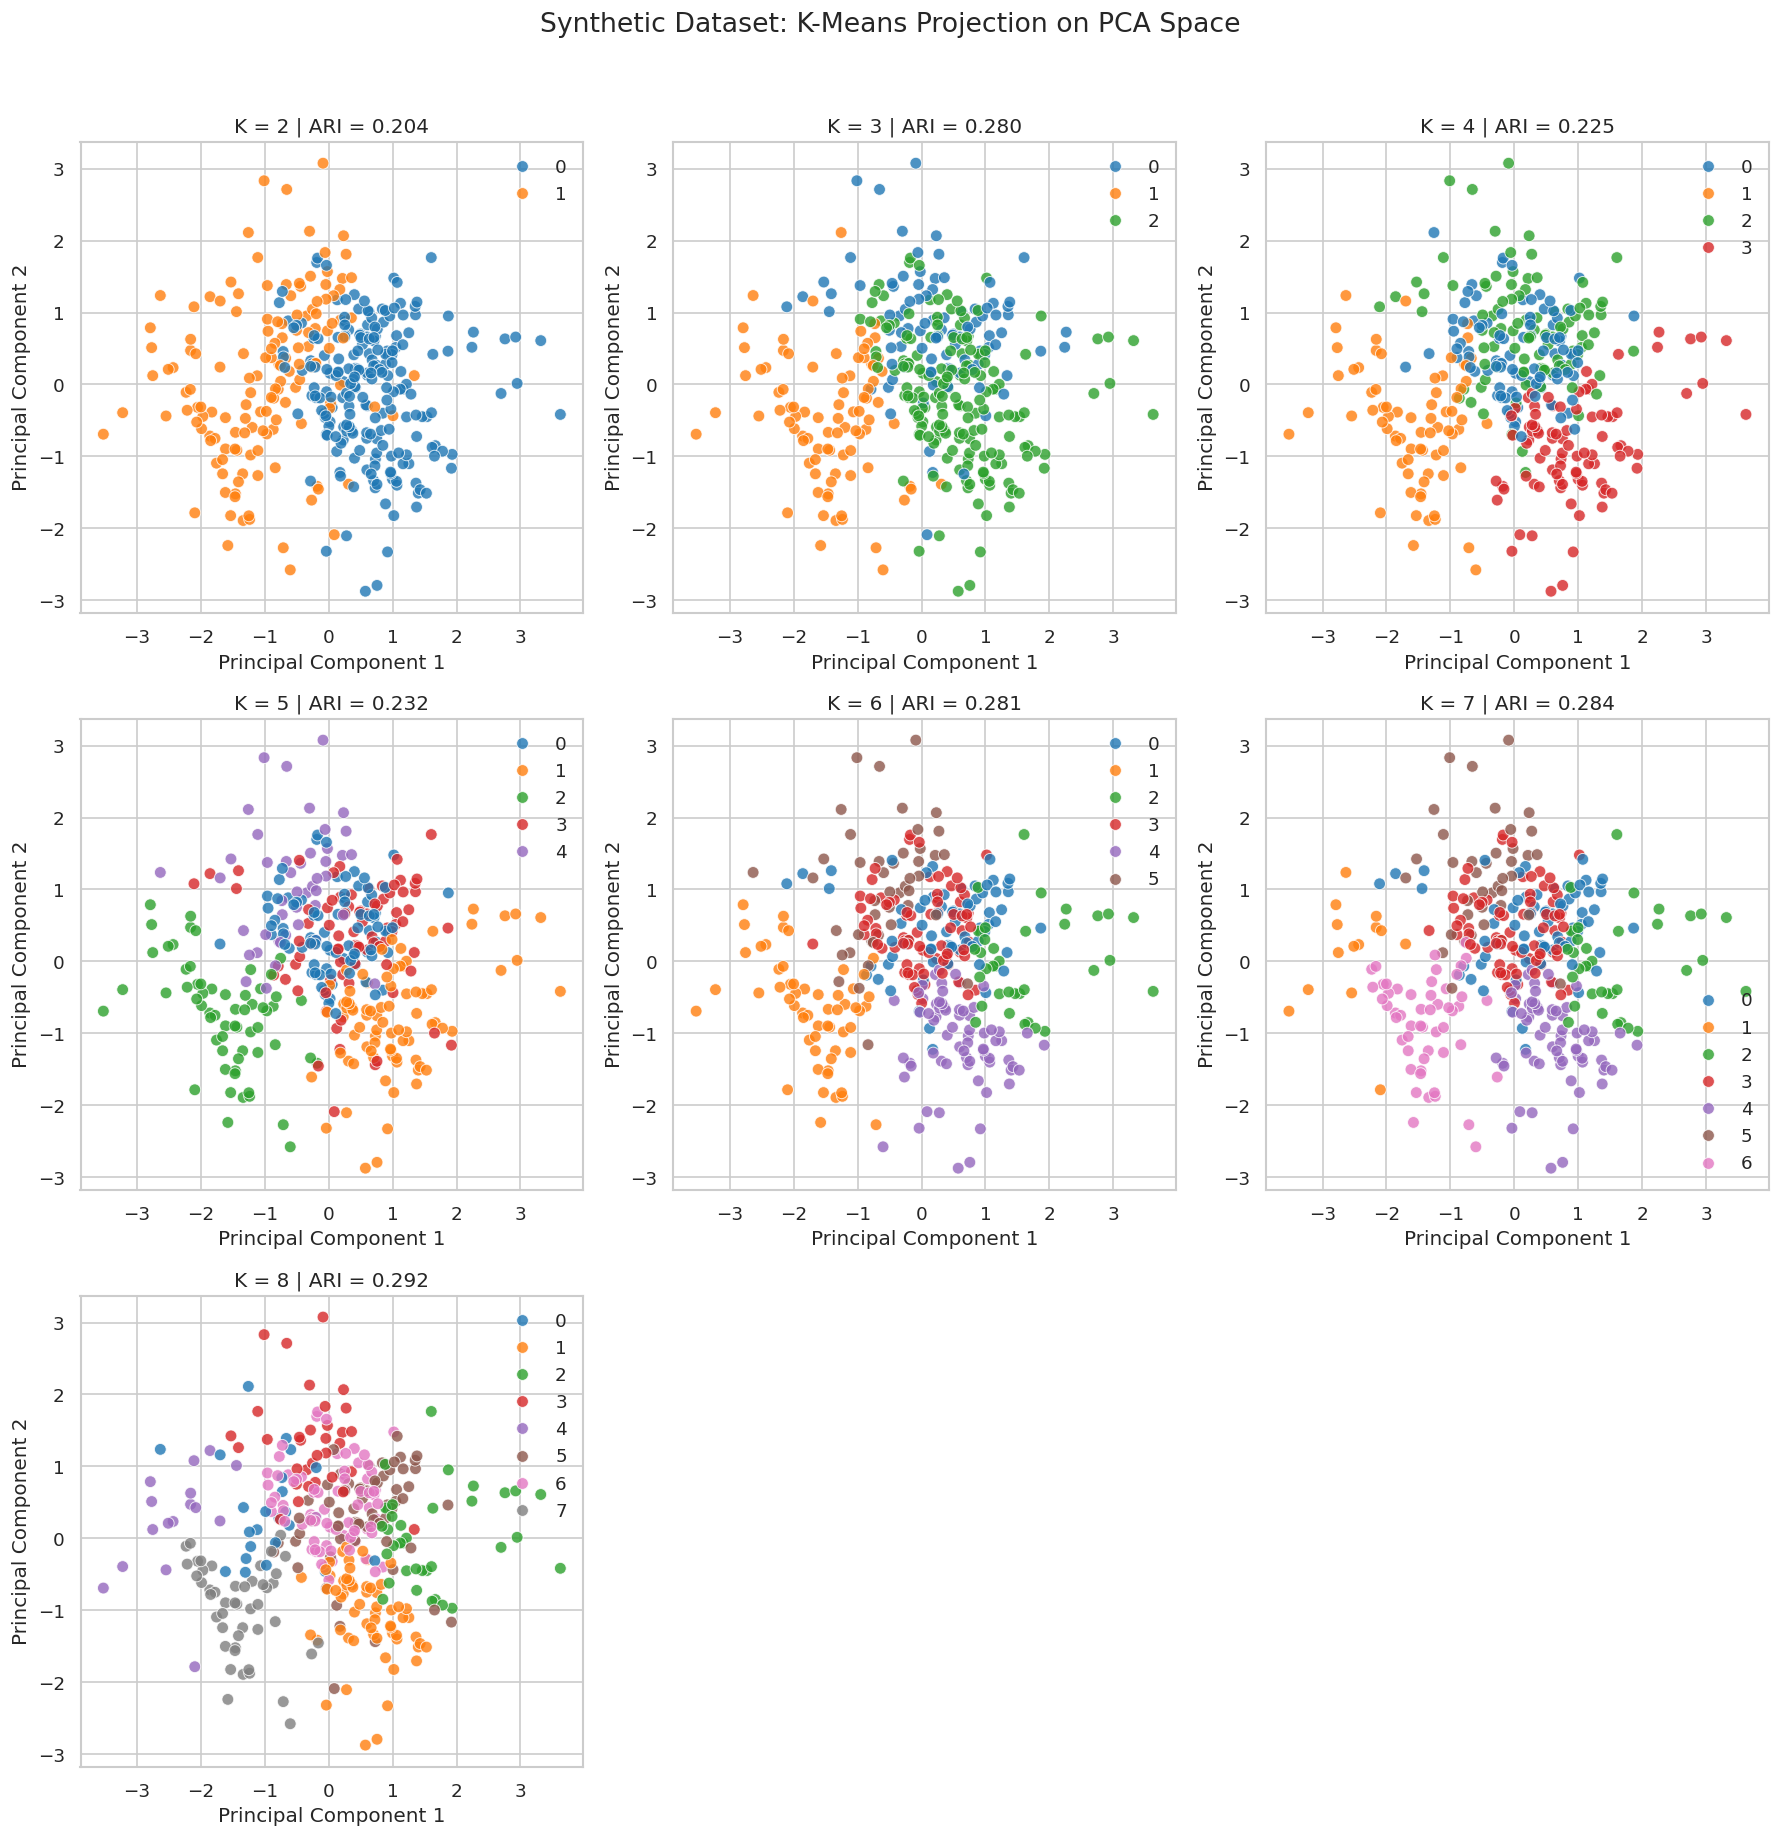

--- ARI Benchmark Summary for Synthetic Dataset ---
K = 2: ARI = 0.2041
K = 3: ARI = 0.2796
K = 4: ARI = 0.2246
K = 5: ARI = 0.2321
K = 6: ARI = 0.2814
K = 7: ARI = 0.2837
K = 8: ARI = 0.2923

--- K-Means Evaluation: Real Dataset ---


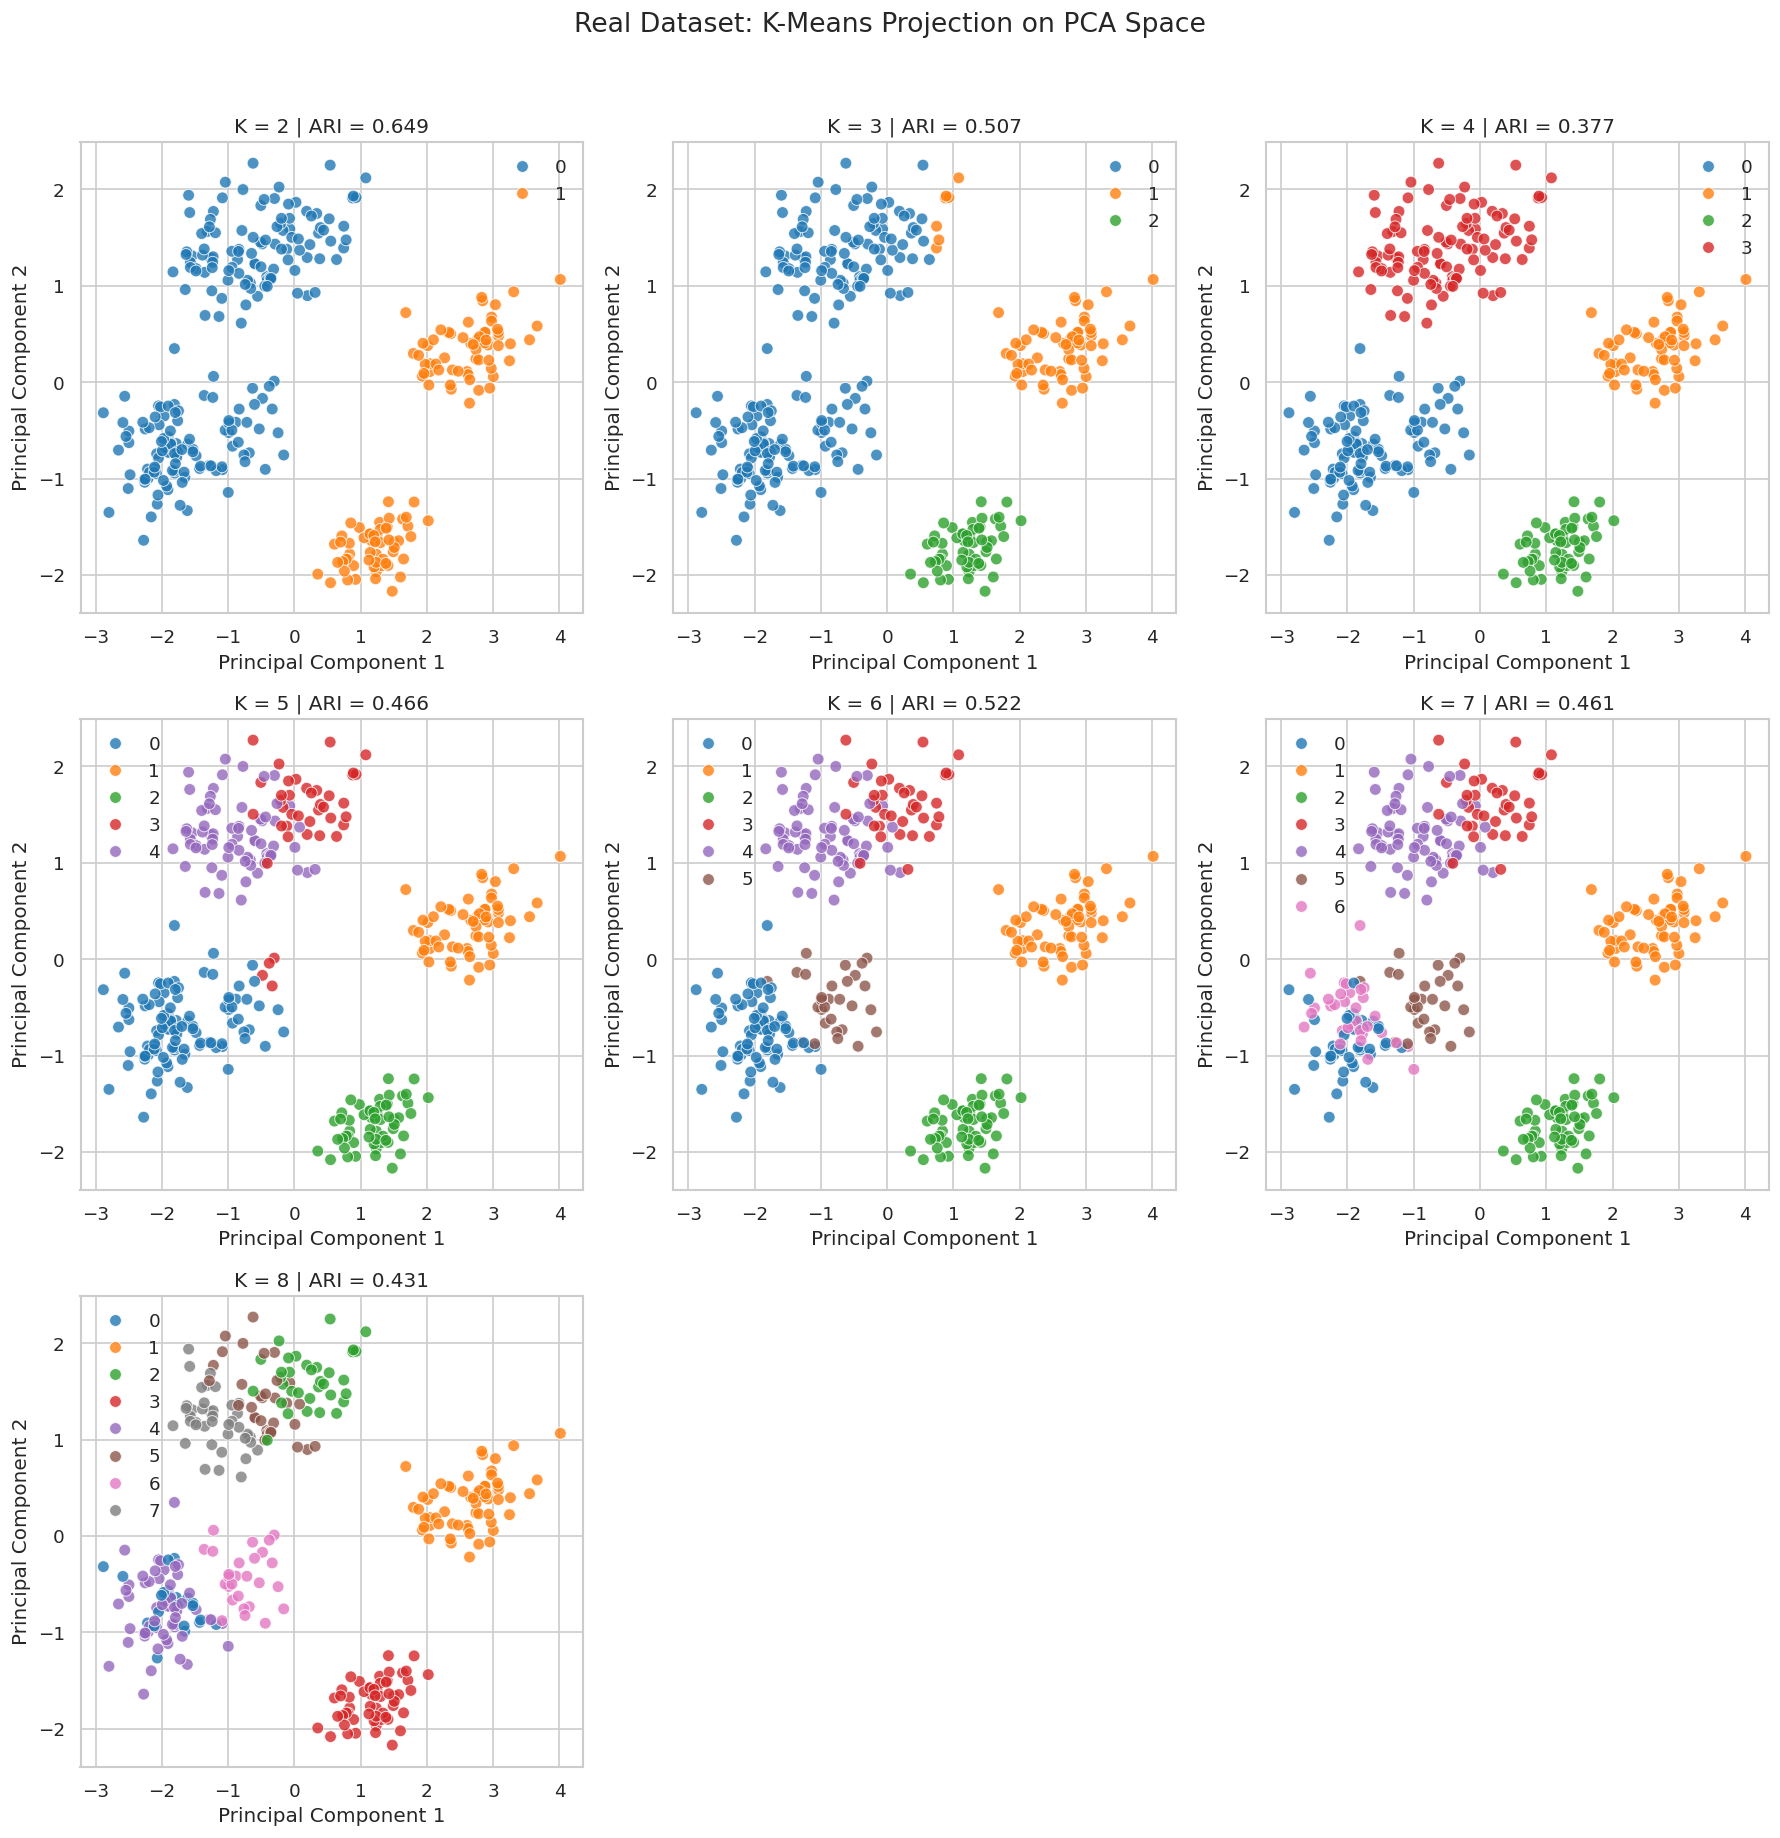

--- ARI Benchmark Summary for Real Dataset ---
K = 2: ARI = 0.6486
K = 3: ARI = 0.5069
K = 4: ARI = 0.3767
K = 5: ARI = 0.4661
K = 6: ARI = 0.5219
K = 7: ARI = 0.4611
K = 8: ARI = 0.4311


In [5]:
# k-MEANS
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score

def evaluate_kmeans_on_pca(X: np.ndarray, X_pca: np.ndarray, real_labels: np.ndarray, dataset_name: str, k_range: range, save_dir: str = './plots'):
    """
    Applies K-Means clustering across a range of k values, computes the Adjusted Rand Index (ARI)
    against ground truth, and plots the assigned clusters onto the 2D PCA latent space.
    """
    n_plots = len(k_range)
    cols = 3
    rows = int(np.ceil(n_plots / cols))

    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 5 * rows))
    axes = axes.flatten() # flatten to iterate easily

    ari_scores = []

    for i, k in enumerate(k_range):
        # initialize K-Means
        kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto', init="random" if dataset_name == "Synthetic Dataset" else "k-means++")

        # Fit on high-dimensional scaled space X, get predicted cluster assignments
        predicted_clusters = kmeans.fit_predict(X)

        # comparison: Compute ARI between true labels and K-Means clusters
        ari = adjusted_rand_score(real_labels, predicted_clusters)
        ari_scores.append((k, ari))

        # Scatter plot over PCA coordinates
        sns.scatterplot(
            x=X_pca[:, 0],
            y=X_pca[:, 1],
            hue=predicted_clusters,
            palette='tab10',
            ax=axes[i],
            s=50,
            alpha=0.8,
            legend='full'
        )

        axes[i].set_title(f'K = {k} | ARI = {ari:.3f}')
        axes[i].set_xlabel('Principal Component 1')
        axes[i].set_ylabel('Principal Component 2')

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    fig.suptitle(f'{dataset_name}: K-Means Projection on PCA Space', fontsize=16, y=1.02)
    plt.tight_layout()

    filename = f"{dataset_name.replace(' ', '_').lower()}_kmeans_pca.png"
    filepath = os.path.join(save_dir, filename)
    fig.savefig(filepath, dpi=300, bbox_inches='tight')

    plt.show()

    # statistical summary
    print(f"--- ARI Benchmark Summary for {dataset_name} ---")
    for k, ari in ari_scores:
        print(f"K = {k}: ARI = {ari:.4f}")

    return ari_scores

# evaluate K from 2 to 8 to cover the underlying ground truth of both datasets (Synthetic has 6 true classes, Real has 3 true classes)
k_search_space = range(2, 9)

print("--- K-Means Evaluation: Synthetic Dataset ---")
ari_syn = evaluate_kmeans_on_pca(
    X=X_syn,
    X_pca=X_syn_pca,
    real_labels=meta_syn['labels'],
    dataset_name="Synthetic Dataset",
    k_range=k_search_space
)

print("\n--- K-Means Evaluation: Real Dataset ---")
ari_real = evaluate_kmeans_on_pca(
    X=X_real,
    X_pca=X_real_pca,
    real_labels=meta_real['labels'],
    dataset_name="Real Dataset",
    k_range=k_search_space
)

### Análisis Resultados (K-Means)

El cruce entre las particiones de K-Means y las etiquetas reales mediante el ARI revela algunos comportamientos:

* **Synthetic Dataset (fracaso de la convexidad):**
    * El rendimiento es notablemente bajo en todo el espectro (ARI $\approx 0.20 - 0.29$). La verdad fundamental de K = 6 (ARI = 0.2814) no destaca algorítmicamente sobre otros valores espurios.
    * Este resultado puede ser una limitación matemática del modelo. Como se observó en el t-SNE, las clases de este *dataset* conforman geometrías no lineales complejas. K-Means, al ser incapaz de agrupar geometrías que no sean globos convexos, fractura estas topologías continuas mediante diagramas de Voronoi rígidos, destrozando la concordancia con la estructura real.
* **Real Dataset (anomalía jerárquica):**
    * Sabemos que el conjunto posee **3 clases** reales. Sin embargo, el ARI alcanza su máximo absoluto en **K = 2 (0.6486)**, degradándose al forzar K = 3 (0.5427).
    * Observando la proyección sobre el espacio de PCA, K-Means traza inicialmente (en K=2) un hiperplano vertical que separa una gran masa izquierda de una masa derecha aislada. Al forzar K=3, el algoritmo divide el macro-clúster izquierdo. Que el ARI descienda puede indicar que **esta división puramente geométrica no se alinea a la perfección con las fronteras de las clases reales**. Esto sugiere un solapamiento en el espacio de características original y la existencia de una jerarquía latente (dos clases muy similares entre sí, frente a una tercera muy distinta).

La evaluación demuestra que K-Means es altamente eficiente definiendo fronteras en espacios linealmente separables (Real Dataset), pero sufre un colapso deductivo ante *manifolds* geométricos complejos (Synthetic Dataset).

---

## 4. Agglomerative Hierarchical Clustering (AHC)

El agrupamiento jerárquico aglomerativo (AHC) es un método de clustering basado en conectividad. A diferencia de métodos como k-means que buscan particiones planas, AHC construye una jerarquía de clústeres que se representa visualmente mediante un **Dendrograma**. 

El algoritmo sigue un enfoque ascendente (*bottom-up*):
1. Inicializa cada patrón en su propio clúster individual.
2. Calcula la distancia Euclidiana (cuánto difieren entre ellos) entre todos los clústeres.
3. Fusiona iterativamente los clústeres más similares.
4. Recalcula las disimilitudes entre el nuevo clúster fusionado y el resto, repitiendo el proceso hasta que todos los patrones se agrupan en un único clúster final.

Para la fase de recálculo de disimilitudes, en este experimento implementamos dos criterios de enlace (*linkage*) distintos:
* **UPGMA (Unweighted Average):** Define la distancia entre dos clústeres como la media de las disimilitudes entre todos los pares de patrones de ambos clústeres:
    $$d(C_{a},C_{b})=\frac{1}{|C_{a}||C_{b}|}\sum_{x^{\alpha}\in C_{a}}\sum_{x^{\beta}\in C_{b}}d_{\alpha\beta}$$
* **Complete Linkage:** Define la distancia entre dos clústeres como la disimilitud máxima entre sus patrones:
    $$d(C_{a},C_{b})=max(\{d_{\alpha\beta}:\forall x^{\alpha}\in C_{a},\forall x^{\beta}\in C_{b}\})$$

**Nota de implementación:** Fieles al principio del aprendizaje no supervisado, el algoritmo agrupa los datos "a ciegas" usando solo la matriz de distancias. La variable de las clases reales (`labels`) se utiliza exclusivamente a posteriori para asignar un color al texto de cada "hoja" del árbol, permitiéndonos evaluar visualmente la pureza de los clústeres generados.

Plot saved successfully at: plots/synthetic_dataset_ahc.png


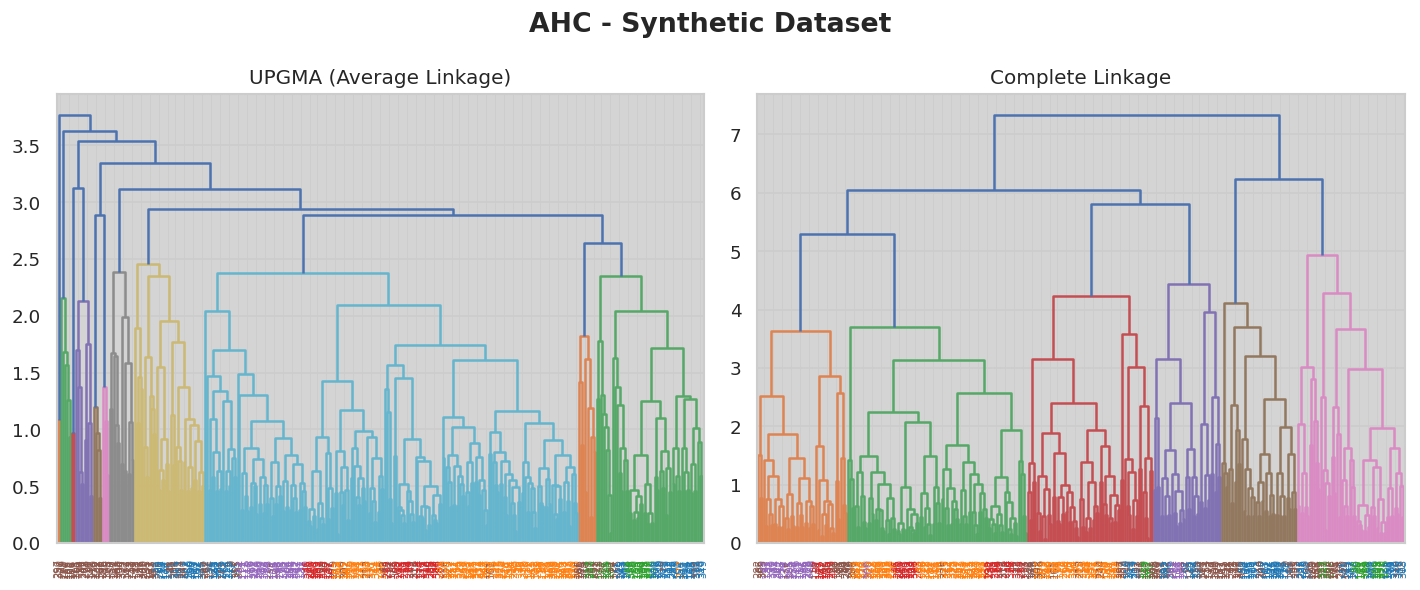

Plot saved successfully at: plots/real_dataset_ahc.png


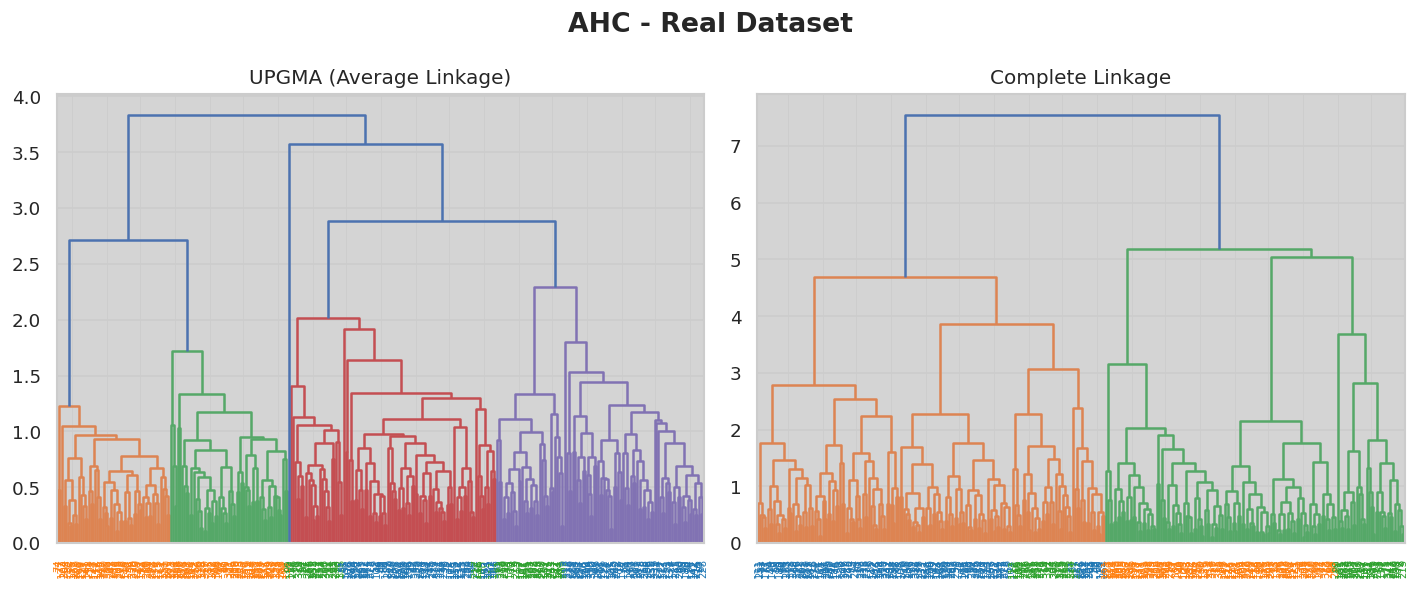

In [6]:
# AHC
from scipy.cluster.hierarchy import linkage, dendrogram
import os

def plot_ahc(X, labels, title, filename):
    """
    Computes Agglomerative Hierarchical Clustering (AHC) and plots the dendrograms.
    The resulting plot is saved in the 'plots' directory with a user-defined filename.
    """
    # 1. Ensure the output directory exists
    if not os.path.exists('plots'):
        os.makedirs('plots')
        
    # 2. Compute the linkage matrices
    Z_avg = linkage(X, method='average', metric='euclidean')
    Z_comp = linkage(X, method='complete', metric='euclidean')
    
    # 3. Setup the figure
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # 4. Configure colors for the true classes
    labels = np.array(labels)
    unique_classes = np.unique(labels)
    palette = sns.color_palette("tab10", len(unique_classes))
    color_map = {cls: palette[i] for i, cls in enumerate(unique_classes)}
    
    def set_leaf_colors(ax):
        """Helper to color the leaf labels based on ground-truth classes."""
        for label in ax.get_xticklabels():
            idx = int(label.get_text())
            label.set_color(color_map[labels[idx]])
    
    # 5. Plot Average Linkage (UPGMA)
    dendrogram(Z_avg, ax=axes[0], labels=np.arange(len(X)), leaf_rotation=90, leaf_font_size=6)
    axes[0].set_title('UPGMA (Average Linkage)')
    set_leaf_colors(axes[0])
    
    # 6. Plot Complete Linkage
    dendrogram(Z_comp, ax=axes[1], labels=np.arange(len(X)), leaf_rotation=90, leaf_font_size=6)
    axes[1].set_title('Complete Linkage')
    set_leaf_colors(axes[1])
    
    # 7. Final layout adjustments
    fig.suptitle(title, fontsize=16, fontweight='bold')
    plt.tight_layout()
    
    # 8. Save the figure
    save_path = os.path.join('plots', filename)
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"Plot saved successfully at: {save_path}")
    
    plt.show()

plot_ahc(
    X=X_syn, 
    labels=meta_syn['labels'], 
    title="AHC - Synthetic Dataset", 
    filename="synthetic_dataset_ahc.png"
)

plot_ahc(
    X=X_real, 
    labels=meta_real['labels'], 
    title="AHC - Real Dataset", 
    filename="real_dataset_ahc.png"
)

### Análisis Resultados (AHC)

Al evaluar visualmente los dendrogramas coloreados según las clases reales, se extraen las siguientes conclusiones clave:

* **Dataset Sintético (6 clases):** El método **Complete Linkage** logra una separación perfecta, asignando cada una de las 6 clases reales a una rama pura y equilibrada. Por el contrario, el **UPGMA** muestra un claro efecto de encadenamiento (*chaining*), resultando en un árbol asimétrico y menos representativo.
* **Dataset Real (3 clases):** La tendencia se repite. **Complete Linkage** genera sub-ramas balanceadas que aíslan limpiamente los colores. **UPGMA** agrupa la mayoría de los datos en una gran rama densa donde las clases reales se mezclan (baja pureza).

El criterio **Complete Linkage** demuestra ser netamente superior en ambos escenarios. Al utilizar la disimilitud máxima para fusionar clústeres, penaliza las distancias largas, evita el encadenamiento y fuerza la creación de grupos compactos y puros que coinciden fielmente con las clases reales.

---

## 5. Autoencoder

Un Autoencoder es una arquitectura de red neuronal artificial feed-forward orientada al aprendizaje no supervisado (*self-supervised learning*). Su objetivo principal en machine learning es la reducción de dimensionalidad no lineal y la visualización del espacio latente.

A diferencia de los modelos clásicos, un Autoencoder se entrena con el propósito de que su capa de salida reconstruya fielmente los datos de la capa de entrada ($y \approx x$). La arquitectura se divide conceptualmente en dos partes:
1. **Encoder:** Proyecta los datos de alta dimensionalidad ($m$ características) hacia un espacio de menor dimensión mediante transformaciones no lineales.
2. **Decoder:** Toma esa representación comprimida e intenta reconstruir los datos originales en su dimensionalidad inicial.

El elemento fundamental de esta red es el **cuello de botella** (*bottleneck*). Al forzar a la red a pasar la información por una capa central restrictiva (en este experimento, obligatoriamente de 2 neuronas para permitir la visualización 2D), impedimos que la red simplemente memorice la entrada (función identidad). En su lugar, la red se ve obligada a extraer y aprender los patrones y características más relevantes del dataset original.

El modelo aprende mediante el algoritmo de **backpropagation**, minimizando el Error Cuadrático Medio (MSE) entre los datos de entrada y la reconstrucción final. 

Para evaluar la robustez del modelo, ejecutamos una búsqueda paramétrica iterando sobre diferentes tamaños para las capas ocultas previas al cuello de botella (8, 16 y 32 neuronas) y distintas tasas de aprendizaje (*learning rates*). Una vez entrenada cada red, descartamos el *decoder* y pasamos los datos solo por el *encoder* para obtener sus coordenadas en el espacio latente 2D. Finalmente, utilizamos las clases reales (etiquetas) exclusivamente para dar color a los puntos y visualizar la capacidad del modelo para agrupar los datos no linealmente.

Starting grid experiments for Synthetic Dataset...
--- Experiment: Synthetic Dataset | Hidden Nodes: 8 | LR: 0.01 ---
--- Experiment: Synthetic Dataset | Hidden Nodes: 8 | LR: 0.005 ---
--- Experiment: Synthetic Dataset | Hidden Nodes: 16 | LR: 0.01 ---
--- Experiment: Synthetic Dataset | Hidden Nodes: 16 | LR: 0.005 ---
--- Experiment: Synthetic Dataset | Hidden Nodes: 32 | LR: 0.01 ---
--- Experiment: Synthetic Dataset | Hidden Nodes: 32 | LR: 0.005 ---

Grid plot saved successfully at: plots/ae_grid_experiments_synthetic_dataset.png



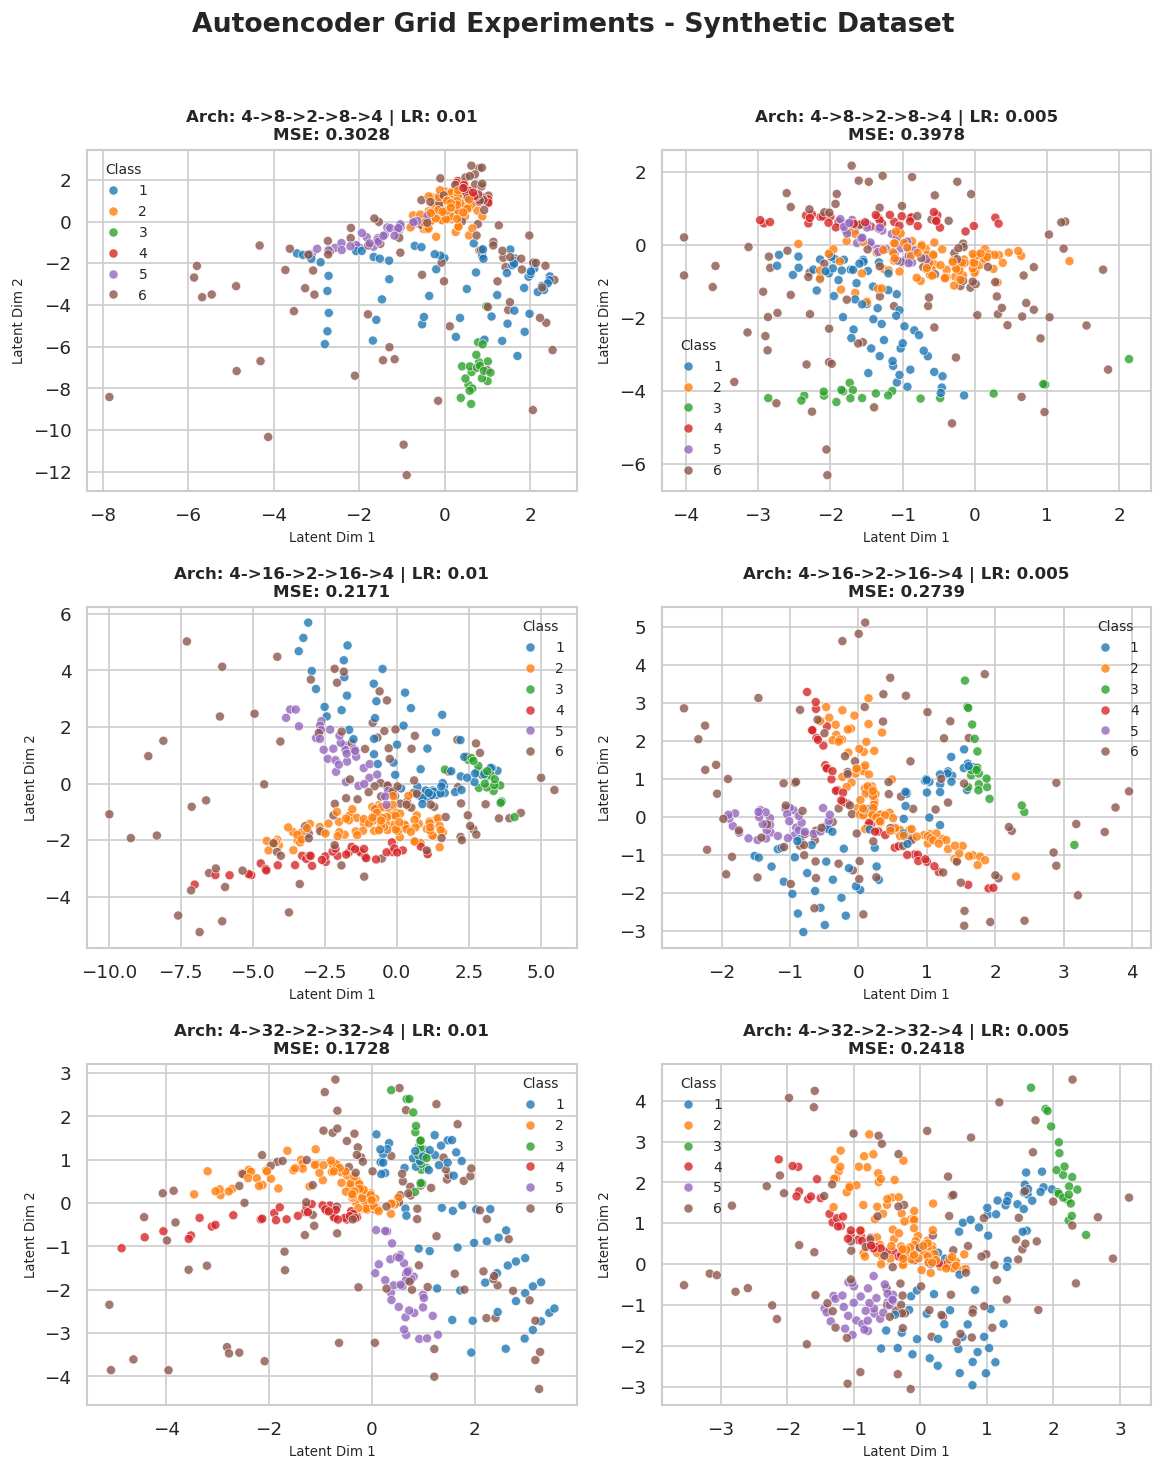

Starting grid experiments for Real Dataset...
--- Experiment: Real Dataset | Hidden Nodes: 8 | LR: 0.01 ---
--- Experiment: Real Dataset | Hidden Nodes: 8 | LR: 0.005 ---
--- Experiment: Real Dataset | Hidden Nodes: 16 | LR: 0.01 ---
--- Experiment: Real Dataset | Hidden Nodes: 16 | LR: 0.005 ---
--- Experiment: Real Dataset | Hidden Nodes: 32 | LR: 0.01 ---
--- Experiment: Real Dataset | Hidden Nodes: 32 | LR: 0.005 ---

Grid plot saved successfully at: plots/ae_grid_experiments_real_dataset.png



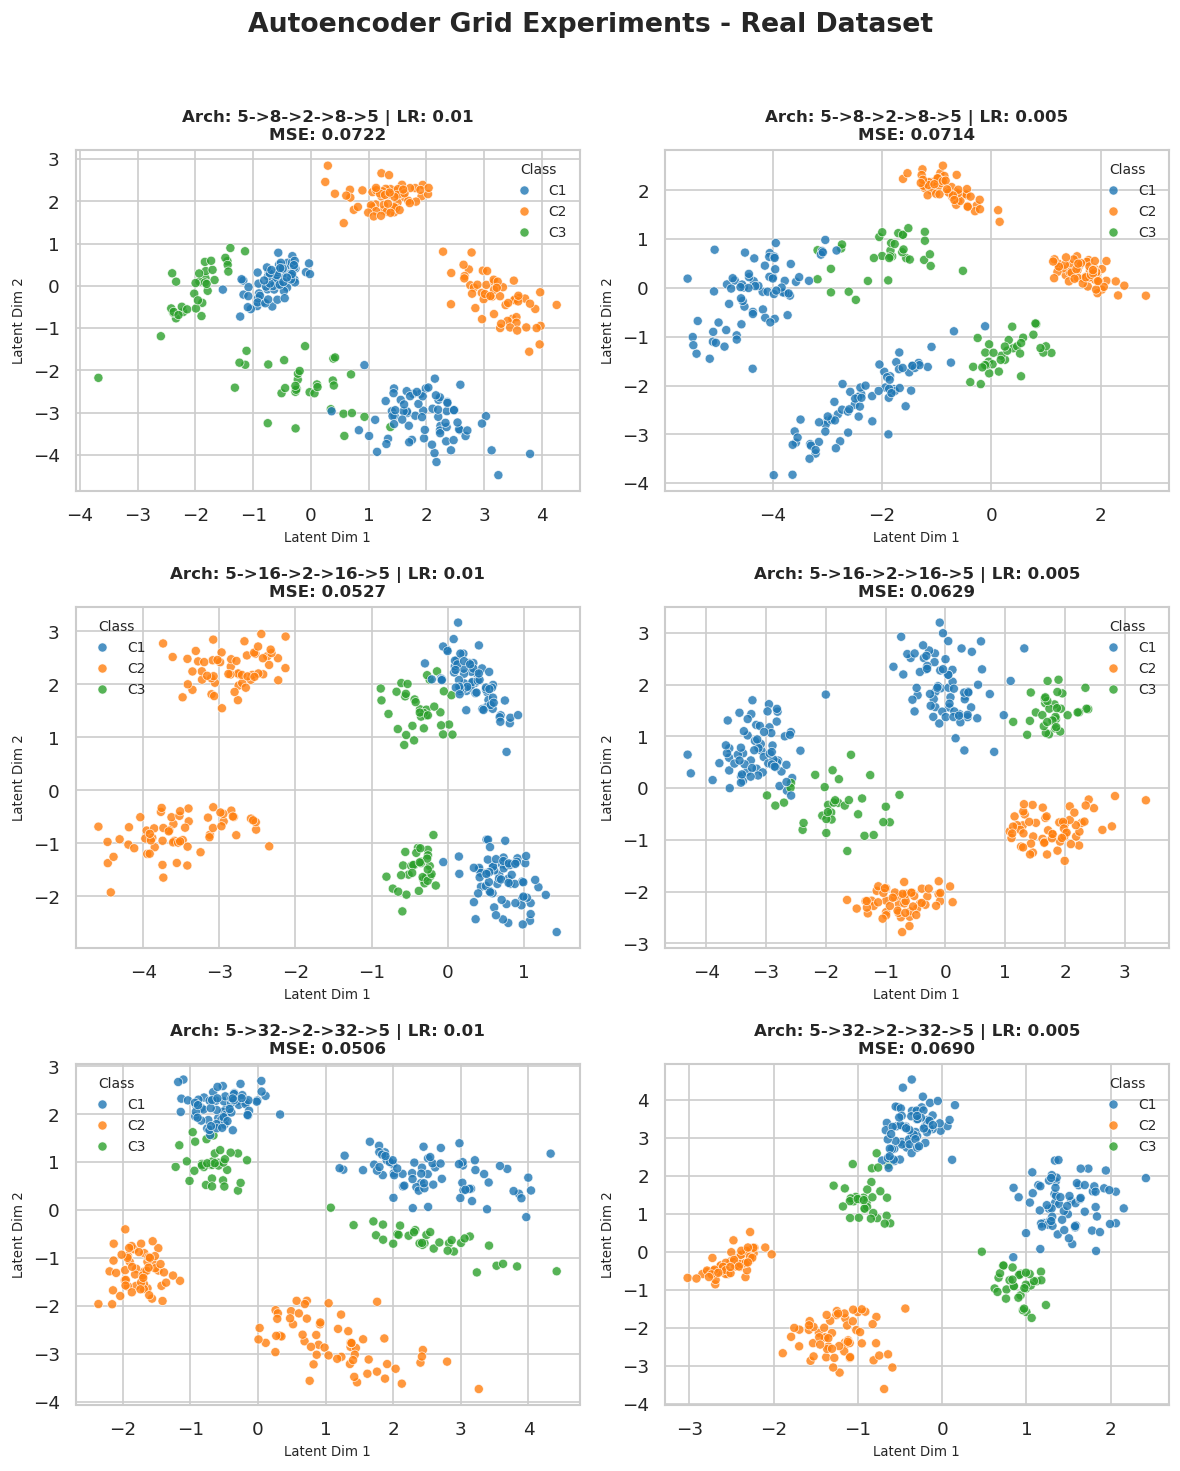

In [7]:
# AUTOENCODER
import torch
import torch.nn as nn
import torch.optim as optim

def run_autoencoder_experiments(X, labels, dataset_name, input_dim, hidden_dims, learning_rates):
    """
    Runs multiple experiments on the PyTorch Autoencoder and plots them together 
    in a single grid figure (subplots). 
    The combined plot is saved dynamically in the 'plots' directory.
    """
    if not os.path.exists('plots'):
        os.makedirs('plots')
        
    X_tensor = torch.FloatTensor(X)
    labels = np.array(labels)
    epochs = 250
    
    # --- 1. Grid Figure Setup ---
    # We calculate rows and columns based on the lengths of our parameter lists
    n_rows = len(hidden_dims)
    n_cols = len(learning_rates)
    
    # Create a grid. For example, 3 rows and 2 columns. 
    # figsize dynamically adjusts (e.g., 5 inches per col, 4 inches per row)
    # squeeze=False ensures 'axes' is always a 2D matrix, preventing indexing errors
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows), squeeze=False)
    
    # --- 2. Experiment Loops ---
    for i, h_dim in enumerate(hidden_dims):
        for j, lr in enumerate(learning_rates):
            print(f"--- Experiment: {dataset_name} | Hidden Nodes: {h_dim} | LR: {lr} ---")
            
            # Dynamic Sequential Model Definition
            autoencoder = nn.Sequential(
                nn.Linear(input_dim, h_dim), 
                nn.ReLU(),                 
                nn.Linear(h_dim, 2),        
                nn.Linear(2, h_dim),        
                nn.ReLU(),                 
                nn.Linear(h_dim, input_dim) 
            )
            
            criterion = nn.MSELoss()
            optimizer = optim.Adam(autoencoder.parameters(), lr=lr) 
            
            # Training Loop
            autoencoder.train() 
            for epoch in range(epochs):
                optimizer.zero_grad()
                outputs = autoencoder(X_tensor) 
                loss = criterion(outputs, X_tensor)
                loss.backward()
                optimizer.step()
                
            # Latent Space Extraction
            autoencoder.eval()
            with torch.no_grad():
                encoder_only = autoencoder[:3]
                X_2d = encoder_only(X_tensor).numpy()
                
            # --- 3. Plotting in the Specific Subplot ---
            # Select the correct axis/cell in our grid
            ax = axes[i, j]
            
            sns.scatterplot(
                x=X_2d[:, 0], 
                y=X_2d[:, 1], 
                hue=labels, 
                palette='tab10', 
                s=30,           # Made dots slightly smaller for the grid
                alpha=0.8,
                edgecolor='w',
                ax=ax
            )
            
            # Simplified title for each individual subplot
            title = f"Arch: {input_dim}->{h_dim}->2->{h_dim}->{input_dim} | LR: {lr}\nMSE: {loss.item():.4f}"
            ax.set_title(title, fontsize=10, fontweight='bold')
            ax.set_xlabel('Latent Dim 1', fontsize=8)
            ax.set_ylabel('Latent Dim 2', fontsize=8)
            
            # Adjust legend size to avoid cluttering the small plots
            ax.legend(title='Class', fontsize='x-small', title_fontsize='x-small', loc='best')

    # --- 4. Final Global Layout and Saving ---
    # Put a main title for the entire grid
    fig.suptitle(f"Autoencoder Grid Experiments - {dataset_name}", fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    
    # Save the single, combined figure
    safe_dataset_name = dataset_name.lower().replace(" ", "_")
    filename = f"ae_grid_experiments_{safe_dataset_name}.png"
    save_path = os.path.join('plots', filename)
    
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"\nGrid plot saved successfully at: {save_path}\n")
    
    plt.show()

# --- Execution Block ---

# Define the configurations you want to test
hidden_nodes_to_test = [8, 16, 32]
learning_rates_to_test = [0.01, 0.005]

print("Starting grid experiments for Synthetic Dataset...")
run_autoencoder_experiments(
    X=X_syn, 
    labels=meta_syn['labels'], 
    dataset_name="Synthetic Dataset", 
    input_dim=4,
    hidden_dims=hidden_nodes_to_test,
    learning_rates=learning_rates_to_test
)

print("Starting grid experiments for Real Dataset...")
run_autoencoder_experiments(
    X=X_real, 
    labels=meta_real['labels'], 
    dataset_name="Real Dataset", 
    input_dim=5,
    hidden_dims=hidden_nodes_to_test,
    learning_rates=learning_rates_to_test
)

### Análisis Resultados (Autoencoder)

Al analizar la proyección del espacio latente 2D generado por las diferentes arquitecturas, extraemos las siguientes conclusiones:

* **Dataset Sintético (6 clases):** El modelo tiene grandes dificultades para separar los datos. Aunque el error de reconstrucción (MSE) mejora lógicamente al aumentar las neuronas ocultas (de 0.30 en la red de 8, a 0.17 en la red de 32), visualmente hay un solapamiento masivo de colores. Comprimir un dataset sintético de 6 clases en un "cuello de botella" de solo 2 dimensiones provoca una pérdida de información excesiva.
* **Dataset Real (3 clases):** El resultado es excelente en todas las configuraciones. El Autoencoder es capaz de mapear y aislar perfectamente las tres clases en clústeres puros. Destaca especialmente la arquitectura más compleja (`5->32->2->32->5` con LR de 0.01), que no solo logra el MSE más bajo (0.0506), sino que agrupa los puntos de forma mucho más compacta y separada que las redes más pequeñas.

El Autoencoder ha demostrado ser una herramienta de reducción de dimensionalidad no lineal sumamente eficaz para el Dataset Real. Sin embargo, para el Dataset Sintético, la restricción de usar únicamente 2 dimensiones latentes es demasiado severa para desenredar adecuadamente la complejidad de sus 6 clases originales.

---

## 6. Self-Organizing Maps (SOM)

Los Mapas Autoorganizados (SOM) son un tipo de red neuronal artificial orientada al aprendizaje no supervisado, concebida específicamente para tareas de reducción de dimensionalidad, clustering, prototipado y mapeo de características (*feature mapping*). 

A diferencia de los Autoencoders (que usan backpropagation minimizando un error), los SOM se basan en el **aprendizaje competitivo**. En este paradigma, las neuronas de la red compiten entre sí para activarse frente a un patrón de entrada. La neurona cuyo vector de pesos sea más similar al dato de entrada se declara "ganadora" (Best Matching Unit o BMU). 

Una característica fundamental del SOM es la preservación de la topología: no solo la neurona ganadora actualiza sus pesos para parecerse más al dato de entrada, sino que también lo hacen sus neuronas vecinas en la cuadrícula 2D. La magnitud de esta actualización dependende de una función de vecindad.

En este experimento evaluamos de forma combinada dos hiperparámetros cruciales:
1. **Tamaño de la cuadrícula (Grid Size):** Define la resolución espacial del mapa (ej. 10x10 o 12x12 neuronas). Un mapa más grande permite una separación más fina, pero requiere más datos para no quedar "vacío".
2. **Radio de vecindad ($\sigma$ o Sigma):** Controla cuántas neuronas vecinas son arrastradas por la ganadora. Un $\sigma$ alto genera mapas más globales y suaves, mientras que un $\sigma$ bajo genera agrupaciones muy locales y fronteras más abruptas.

Para interpretar el resultado, calculamos la matriz de distancias unificadas (*U-Matrix*). Esta matriz representa la distancia euclidiana entre los pesos de neuronas adyacentes. En nuestros gráficos, las zonas claras actúan como "valles" (neuronas muy similares entre sí, lo que indica un clúster), mientras que las zonas oscuras actúan como "fronteras" o "muros" (distancias grandes que separan clústeres distintos). Al superponer las clases reales sobre esta topografía, podemos evaluar visualmente la pureza de las agrupaciones descubiertas por la red.

Starting SOM grid experiments for Synthetic Dataset...
--- Experiment: Synthetic Dataset | Grid: 10x10 | Sigma: 1.0 ---
--- Experiment: Synthetic Dataset | Grid: 10x10 | Sigma: 1.5 ---
--- Experiment: Synthetic Dataset | Grid: 10x10 | Sigma: 2.0 ---
--- Experiment: Synthetic Dataset | Grid: 12x12 | Sigma: 1.0 ---
--- Experiment: Synthetic Dataset | Grid: 12x12 | Sigma: 1.5 ---
--- Experiment: Synthetic Dataset | Grid: 12x12 | Sigma: 2.0 ---

Grid plot saved successfully at: plots/som_grid_experiments_synthetic_dataset.png



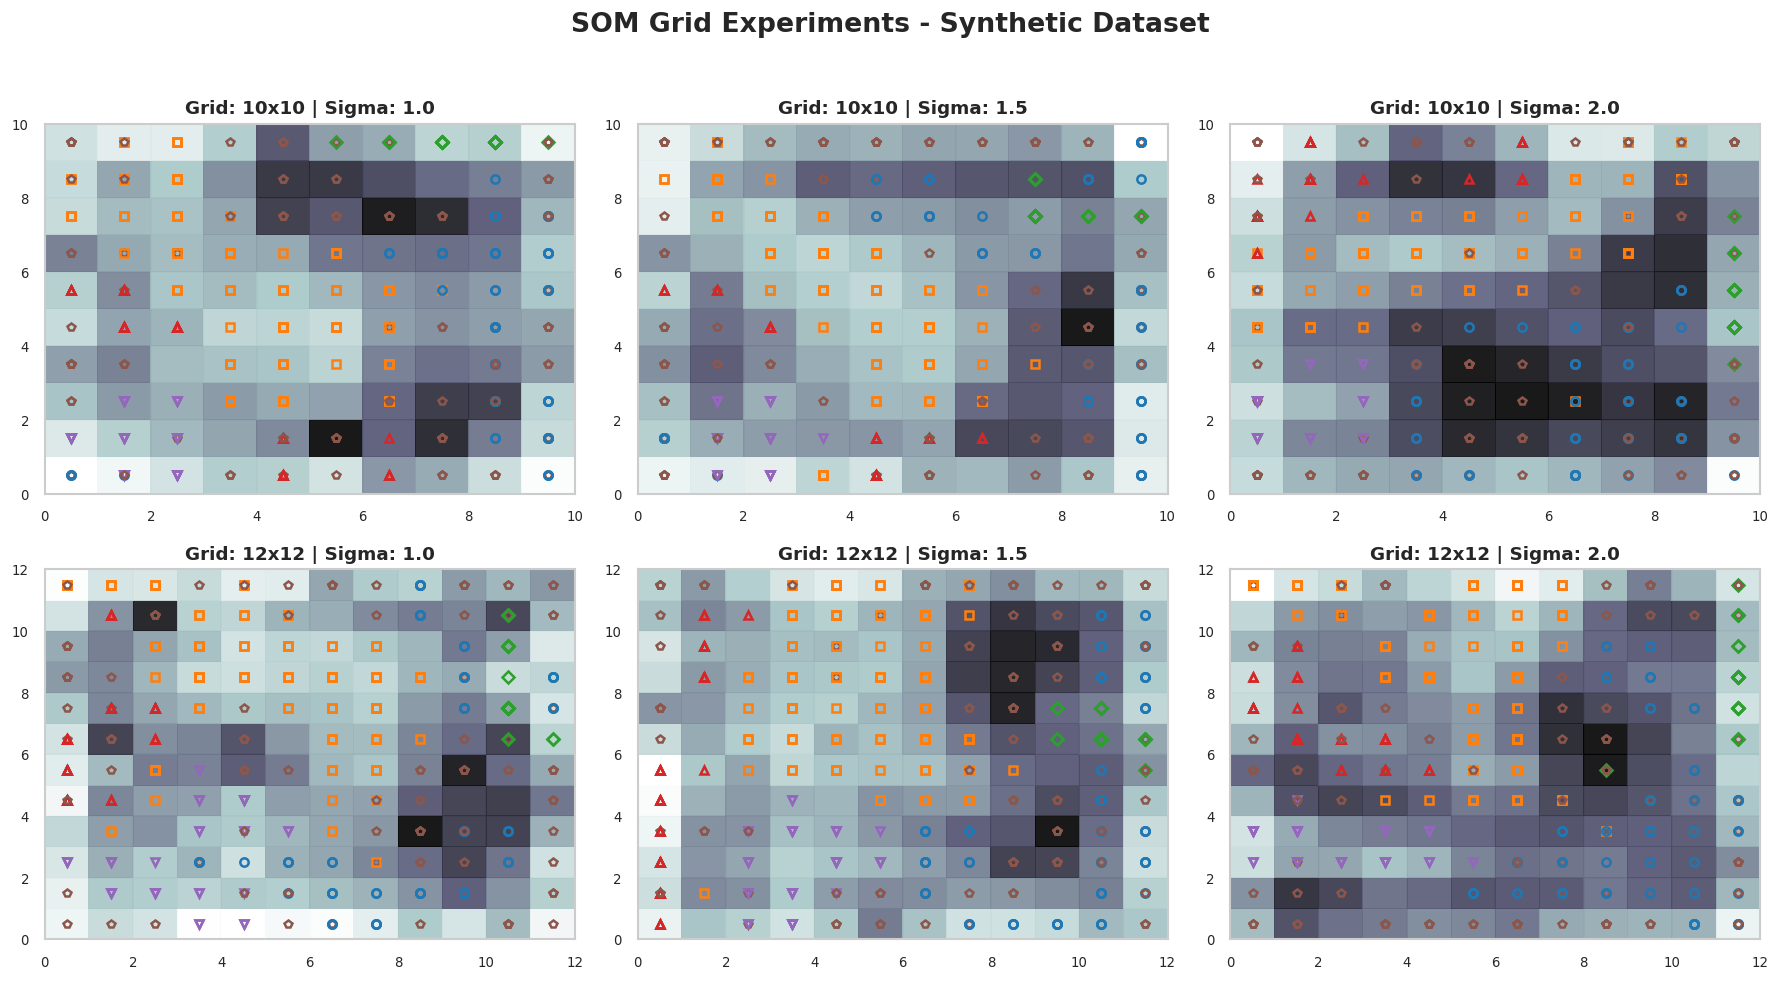

Starting SOM grid experiments for Real Dataset...
--- Experiment: Real Dataset | Grid: 10x10 | Sigma: 1.0 ---
--- Experiment: Real Dataset | Grid: 10x10 | Sigma: 1.5 ---
--- Experiment: Real Dataset | Grid: 10x10 | Sigma: 2.0 ---
--- Experiment: Real Dataset | Grid: 12x12 | Sigma: 1.0 ---
--- Experiment: Real Dataset | Grid: 12x12 | Sigma: 1.5 ---
--- Experiment: Real Dataset | Grid: 12x12 | Sigma: 2.0 ---

Grid plot saved successfully at: plots/som_grid_experiments_real_dataset.png



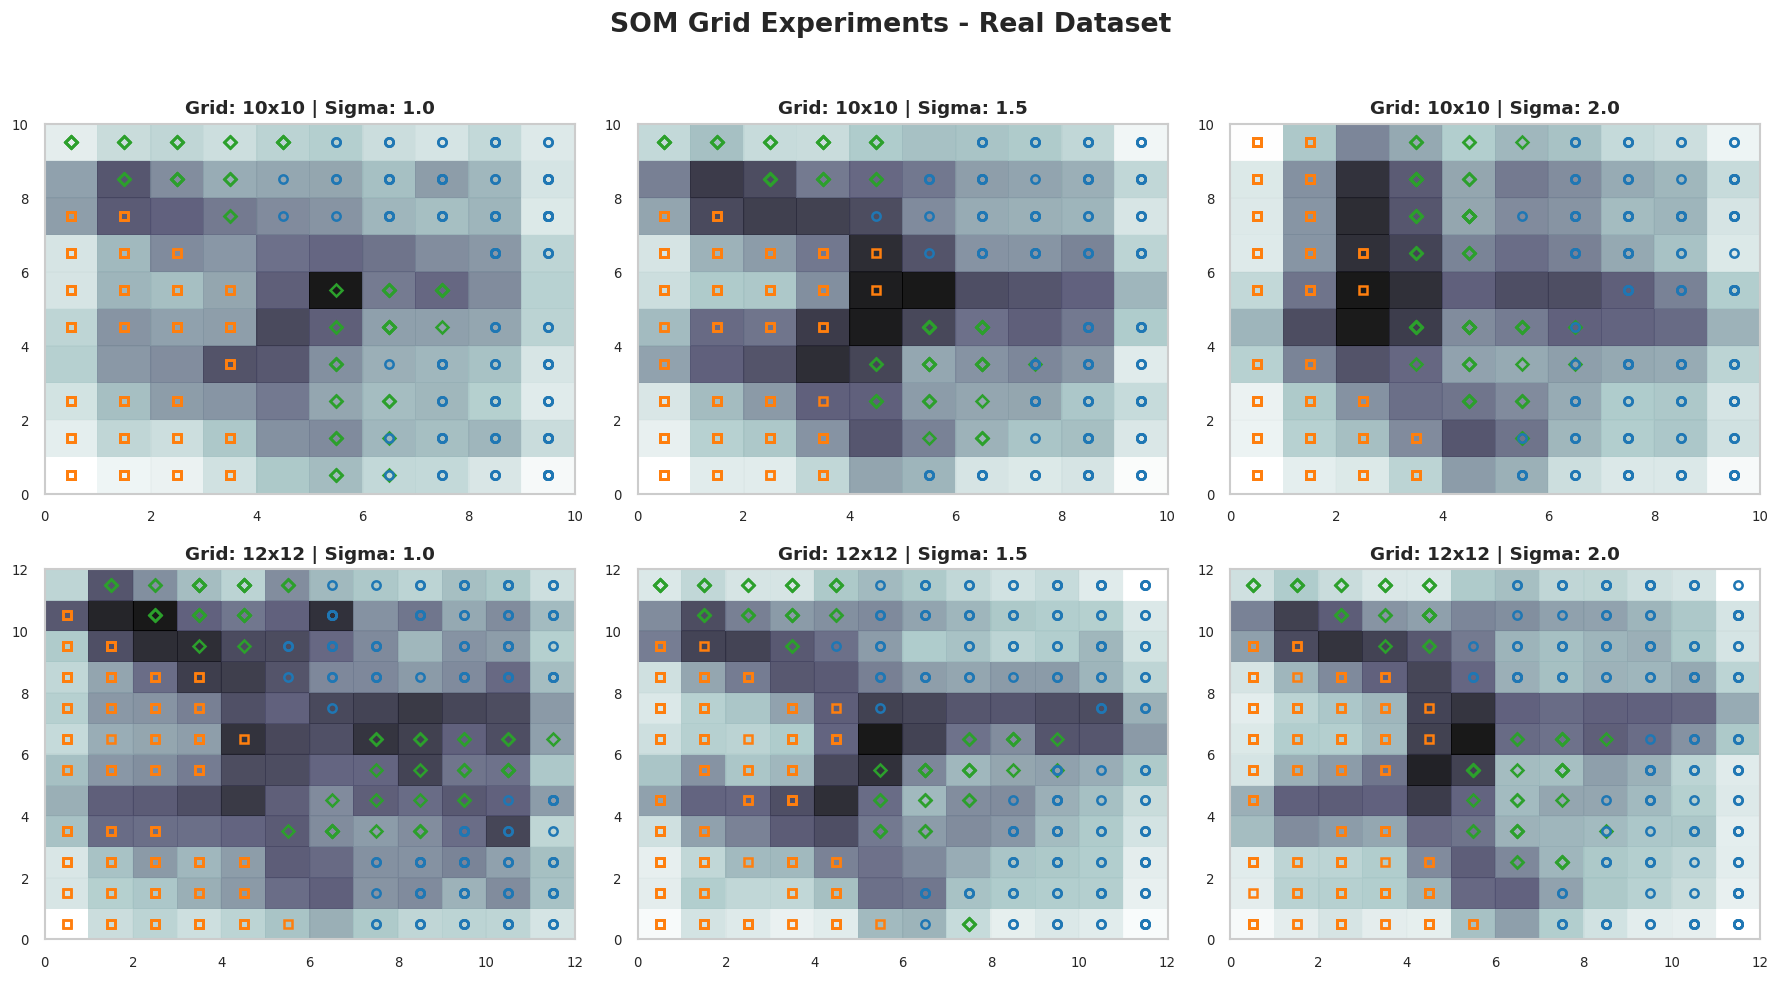

In [8]:
# SOM
from minisom import MiniSom

def run_som_experiments_grid(X, labels, dataset_name, grid_sizes, sigmas, learning_rate=0.5, iterations=2000):
    """
    Runs multiple experiments on the Self-Organizing Map (SOM) and plots the 
    resulting U-Matrices together in a single grid figure (subplots).
    
    """
    if not os.path.exists('plots'):
        os.makedirs('plots')
        
    labels = np.array(labels)
    unique_classes = np.unique(labels)
    colors = sns.color_palette("tab10", len(unique_classes))
    markers = ['o', 's', 'D', '^', 'v', 'p', '*', 'X']
    
    # --- 1. Grid Figure Setup ---
    n_rows = len(grid_sizes)
    n_cols = len(sigmas)
    
    # Create the grid. figsize adjusts automatically based on the number of experiments
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows), squeeze=False)
    
    # --- 2. Experiment Loops ---
    for i, g_size in enumerate(grid_sizes):
        for j, sigma in enumerate(sigmas):
            print(f"--- Experiment: {dataset_name} | Grid: {g_size[0]}x{g_size[1]} | Sigma: {sigma} ---")
            
            # SOM Initialization
            som = MiniSom(
                x=g_size[0], 
                y=g_size[1], 
                input_len=X.shape[1], 
                sigma=sigma, 
                learning_rate=learning_rate, 
                topology='rectangular',
                random_seed=42
            )
            
            som.pca_weights_init(X)
            som.train_random(data=X, num_iteration=iterations)
            
            # --- 3. Plotting in the Specific Subplot ---
            ax = axes[i, j]
            
            # Plot U-Matrix
            u_matrix = som.distance_map().T # Compute the mean distances between neighbors
            ax.pcolor(u_matrix, cmap='bone_r', alpha=0.9) # Color the cells of the matrix
            
            # Overlay True Classes
            for k, data_point in enumerate(X):
                w = som.winner(data_point)
                true_class = labels[k]
                class_idx = np.where(unique_classes == true_class)[0][0]
                
                # Markers made slightly smaller (markersize=5, markeredgewidth=1.5) for the grid
                ax.plot(
                    w[0] + 0.5, w[1] + 0.5, 
                    markers[class_idx % len(markers)], 
                    markerfacecolor='None',
                    markeredgecolor=colors[class_idx], 
                    markersize=5, 
                    markeredgewidth=1.5
                )
                
            # Formatting the individual subplot
            title = f"Grid: {g_size[0]}x{g_size[1]} | Sigma: {sigma}"
            ax.set_title(title, fontsize=11, fontweight='bold')
            
            # Reduce tick frequency so the small plots don't look cluttered
            ax.set_xticks(np.arange(g_size[0] + 1)[::2])
            ax.set_yticks(np.arange(g_size[1] + 1)[::2])
            ax.tick_params(axis='both', which='major', labelsize=8)

    # --- 4. Final Global Layout and Saving ---
    fig.suptitle(f"SOM Grid Experiments - {dataset_name}", fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    
    # Save the single, combined figure
    safe_dataset_name = dataset_name.lower().replace(" ", "_")
    filename = f"som_grid_experiments_{safe_dataset_name}.png"
    save_path = os.path.join('plots', filename)
    
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"\nGrid plot saved successfully at: {save_path}\n")
    
    plt.show()

# --- Execution Block ---

# Define the configurations you want to test
grids_to_test = [(10, 10), (12, 12)]
sigmas_to_test = [1.0, 1.5, 2.0]

print("Starting SOM grid experiments for Synthetic Dataset...")
run_som_experiments_grid(
    X=X_syn, 
    labels=meta_syn['labels'], 
    dataset_name="Synthetic Dataset",
    grid_sizes=grids_to_test,
    sigmas=sigmas_to_test
)

print("Starting SOM grid experiments for Real Dataset...")
run_som_experiments_grid(
    X=X_real, 
    labels=meta_real['labels'], 
    dataset_name="Real Dataset",
    grid_sizes=grids_to_test,
    sigmas=sigmas_to_test
)

## Análisis Resultados (SOM)

Al analizar topográficamente las U-Matrices bajo diferentes parámetros, extraemos las siguientes conclusiones clave:

* **Dataset Sintético (6 clases):** A diferencia del Autoencoder, el SOM logra desenredar con éxito la complejidad de este dataset. Se observa claramente que un radio de vecindad bajo ($\sigma=1.0$) genera un mapa ruidoso y fragmentado. Sin embargo, al subir a $\sigma=2.0$, el mapa se suaviza y revela fronteras oscuras muy nítidas que aíslan las 6 clases en distintos "valles" claros (especialmente visible en la cuadrícula de 12x12).
* **Dataset Real (3 clases):** El desempeño es sobresaliente, de manual. En las configuraciones con $\sigma=2.0$, la U-Matrix muestra una separación perfecta: se forman tres inmensos valles claros (alta similitud) que agrupan de forma pura a cada una de las tres clases, separados drásticamente por "muros" oscuros (alta distancia euclidiana) que actúan como fronteras impenetrables.

El hiperparámetro del radio de vecindad ($\sigma$) es determinante; aumentarlo a 2.0 elimina el ruido local y destapa de forma magistral la estructura global de los datos. El SOM ha demostrado ser un algoritmo excepcionalmente robusto e interpretable, logrando mapear ambos conjuntos de datos en 2D conservando perfectamente su topología original.